## Integrated project: Understanding the Yield

In [2]:
# Read the database, and clean the data using the processing modules we built

import re
import numpy as np
import pandas as pd
from field_data_processor import FieldDataProcessor
# from weather_date_processor import WeatherDataProcessor
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

config_params = {
    "sql_query": """
        SELECT *
        FROM geographic_features
        LEFT JOIN weather_features USING (Field_ID)
        LEFT JOIN soil_and_Crop_features USING (Field_ID)
        LEFT JOIN farm_management_features USING (Field_ID)
    """,
    "db_path": 'sqlite:///Maji_Ndogo_farm_survey_small.db',
    "columns_to_rename": {'Annual_yield': 'Crop_type', 'Crop_type': 'Annual_yield'},
    "values_to_rename": {'cassaval': 'cassava', 'wheatn': 'wheat', 'teaa': 'tea'},
    "weather_csv_path": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_station_data.csv",
    "weather_mapping_csv": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv",
    "regex_patterns": {
        'Rainfall': r'(\d+(\.\d+)?)\s?mm',
        'Temperature': r'(\d+(\.\d+)?)\s?C',
        'Pollution_level': r'=\s*(-?\d+(\.\d+)?)|Pollution at \s*(-?\d+(\.\d+)?)'
    },
}

# ignoring the field data for now
field_processor = FieldDataProcessor(config_params)
field_processor.process()
field_df = field_processor.df

# We're not going to use the weather data this time, so we'll ignore it.
# Weather_processor = WeatherDataProcessor(config_params)
# Weather_processor.process()
# Weather_df = weather_processor.weather_df

dataset = field_df.drop("Weather_station", axis=1)

2026-07-19 20:35:37,740 - data_ingestion - INFO - Database engine created successfully.
2026-07-19 20:35:37,825 - data_ingestion - INFO - Query executed successfully.
2026-07-19 20:35:37,826 - field_data_processor.FieldDataProcessor - INFO - Successfully loaded data.
2026-07-19 20:35:37,826 - field_data_processor.FieldDataProcessor - INFO - Swapped columns: Annual_yield with Crop_type
2026-07-19 20:35:52,874 - data_ingestion - INFO - CVS file read successfully from the web.


In [3]:
dataset

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield,Unnamed: 0
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,8.526684e-02,1.3,0.751354,cassava,0.577964,0
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,3.996838e-01,2.2,1.069865,cassava,0.486302,1
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,3.580286e-01,3.4,2.208801,tea,0.649647,2
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,2.866871e-01,2.4,1.277635,cassava,0.532348,3
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,4.319027e-02,1.5,0.832614,wheat,0.555076,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649,11472,681.36145,-7.358371,-6.254369,Rural_Akatsi,16.213196,885.7,-4.3,33.4,14.55,0.61,Sandy,5.741063,3.286828e-01,1.1,0.609930,potato,0.554482,5649
5650,19660,667.02120,-3.154559,-4.475046,Rural_Kilimani,2.397553,501.1,-4.8,32.1,13.65,0.54,Sandy,5.445833,1.602583e-01,8.7,3.812289,maize,0.438194,5650
5651,41296,670.77900,-14.472861,-6.110221,Rural_Hawassa,7.636470,1586.6,-3.8,33.4,14.80,0.64,Volcanic,5.385873,8.221326e-09,2.1,1.681629,tea,0.800776,5651
5652,33090,429.48840,-14.653089,-6.984116,Rural_Hawassa,13.944720,1272.2,-6.2,34.6,14.20,0.63,Silt,5.562508,6.917245e-10,1.3,0.659874,cassava,0.507595,5652


In [27]:
# validate the data
# !pip install pytest

dataset.to_csv('sampled_field_df.csv', index=False)
!pytest validate_data.py -v

import os # Define the file paths
field_csv_path = 'sampled_field_df.csv'

# Delete sampled_field_df.csv if it exists
if os.path.exists(field_csv_path):
    os.remove(field_csv_path)
    print(f"Deleted {field_csv_path}")
else:
    print(f"{field_csv_path} does not exist.")

============================= test session starts =============================
platform win32 -- Python 3.7.1, pytest-7.1.2, pluggy-1.0.0 -- D:\Users\steph\anaconda3\envs\interactive_visuals_ALX\python.exe
cachedir: .pytest_cache
rootdir: D:\ALX\Data Science\Machine Learning\Model Performance 4.0
collecting ... collected 4 items

validate_data.py::test_read_field_dataframe_shape PASSED                 [ 25%]
validate_data.py::test_field_dataframe_columns PASSED                    [ 50%]
validate_data.py::test_field_dataframe_non_negative_elevation PASSED     [ 75%]
validate_data.py::test_crop_types_are_valid PASSED                       [100%]

============================== 4 passed in 0.63s ==============================
Deleted sampled_field_df.csv


In [28]:
dataset.shape

(5654, 18)

In [29]:
dataset.columns

Index(['Field_ID', 'Elevation', 'Latitude', 'Longitude', 'Location', 'Slope',
       'Rainfall', 'Min_temperature_C', 'Max_temperature_C', 'Ave_temps',
       'Soil_fertility', 'Soil_type', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop_type', 'Standard_yield'],
      dtype='object')

In [7]:
dataset.drop('Unnamed: 0', axis=1, inplace=True)

In [30]:
dataset.columns

Index(['Field_ID', 'Elevation', 'Latitude', 'Longitude', 'Location', 'Slope',
       'Rainfall', 'Min_temperature_C', 'Max_temperature_C', 'Ave_temps',
       'Soil_fertility', 'Soil_type', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop_type', 'Standard_yield'],
      dtype='object')

In [26]:
dataset['Crop_type'].unique()

array(['cassava', 'tea', 'wheat', 'potato', 'banana', 'coffee', 'rice',
       'maize'], dtype=object)

In [25]:
dataset['Crop_type'].replace('cassava ', 'cassava', inplace=True)

## Analysis

### Challenge 1: Visualizing the relationship

In [11]:
import matplotlib.pyplot as plt

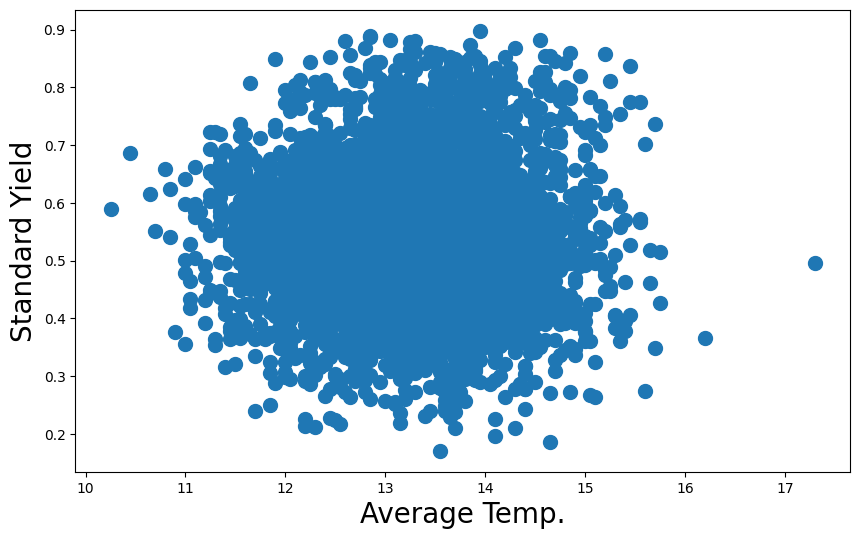

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x=dataset['Ave_temps'], y=dataset['Standard_yield'], s=100)

ax.set_xlabel('Average Temp.', fontsize=20)
ax.set_ylabel('Standard Yield', fontsize=20)
plt.show()

In [13]:
from scipy.stats import pearsonr

In [14]:
def get_correlation(df, col1, col2):
    corr_coef, p_value = pearsonr(df[col1], df[col2])
    return float(corr_coef)

In [15]:
correlation = get_correlation(dataset, 'Ave_temps', 'Standard_yield')
print("Pearson correlation coefficient:", correlation)

Pearson correlation coefficient: 0.0067859502890201834


### Challenge 2: A breath of fresh data - Pollution as a predictor

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
def fit_linear_regression_model(df, pollution_col, yield_col):
    X = df[[pollution_col]]
    y = df[yield_col]
    
    model = LinearRegression()
    model.fit(X, y)
    
    y_pred = model.predict(X)
    
    return model, y_pred, y

In [18]:
model, predictions, y_values = fit_linear_regression_model(dataset, 'Pollution_level', 'Standard_yield')
print(f"Model: {model}")
print(f"Predictions: {predictions}")
print(f"Actual Y-values: {y_values}")

Model: LinearRegression()
Predictions: [0.5540956  0.50920888 0.51515565 ... 0.56626844 0.56626844 0.52896886]
Actual Y-values: 0       0.577964
1       0.486302
2       0.649647
3       0.532348
4       0.555076
          ...   
5649    0.554482
5650    0.438194
5651    0.800776
5652    0.507595
5653    0.453064
Name: Standard_yield, Length: 5654, dtype: float64


In [19]:
# type(model)
# type(predictions)
# type(y_values)

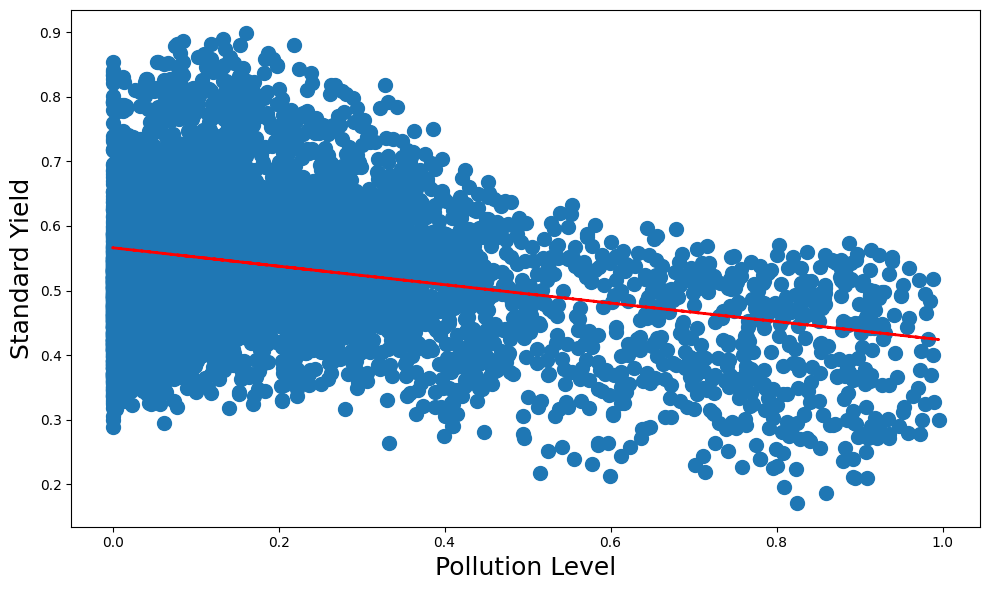

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x=dataset['Pollution_level'], y=dataset['Standard_yield'], s=100)

# Regression model
ax.plot(
    dataset['Pollution_level'],
    predictions,
    color='red',
    linewidth=2,
    linestyle='--',
    label='Regression Line'
)

ax.set_xlabel('Pollution Level', fontsize=18)
ax.set_ylabel('Standard Yield', fontsize=18)

plt.tight_layout()
plt.show()

In [36]:
Pollution_correlation = get_correlation(dataset, 'Pollution_level', 'Standard_yield')
print('Pearson Correlation coefficient:', Pollution_correlation)

Pearson Correlation coefficient: -0.2857609646210545


In [40]:
def get_slope_intercept(model):
    model_slope = model.coef_[0]
    model_intercept = model.intercept_
    return model_slope, model_intercept

In [42]:
slope, intercept = get_slope_intercept(model)
print("Slope: ", slope)
print("Intercept: ", intercept)

Slope:  -0.14276177209866064
Intercept:  0.566268441539338


### Challenge 3: The haze clears - Eveluating pollution's predictive power

In [43]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [44]:
def calculate_evaluation_metrics(predictions, y_values):
    r2 = r2_score(y_values, predictions)
    mae = mean_absolute_error(y_values, predictions)
    mse = mean_squared_error(y_values, predictions)
    rmse = np.sqrt(mse)
    
    return r2, mae, mse, rmse

In [45]:
evaluation_metrics = calculate_evaluation_metrics(predictions, y_values)
print(f"Evaluation Metrics:\nR-squared: {evaluation_metrics[0]}\nMAE: {evaluation_metrics[1]}\nMSE: {evaluation_metrics[2]}\nRMSE: {evaluation_metrics[3]}")

Evaluation Metrics:
R-squared: 0.0816593289011559
MAE: 0.08554642090904992
MSE: 0.011477732254034843
RMSE: 0.10713417873878925


### Challenge 4: The dividing line - Train test split in action

In [46]:
from sklearn.model_selection import train_test_split

In [50]:
def data_train_test_split(df, pollution_col, yield_col):
    X = np.array(df[pollution_col])
    y = df[yield_col]
    
    X = X.reshape(-1, 1)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )
    
    return X_train, X_test, y_train, y_test

In [51]:
X_train, X_test, y_train, y_test = data_train_test_split(dataset, 'Pollution_level', 'Standard_yield')
print(f"X_train Shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train Shape: (4523, 1), X_test shape: (1131, 1)
y_train shape: (4523,), y_test shape: (1131,)


In [52]:
from sklearn.linear_model import LinearRegression

In [55]:
def train_split_linear_regression_model(X_train, X_test, y_train, y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    return model, y_pred, y_test

In [56]:
train_test_model, predictions_test, y_test = train_split_linear_regression_model(X_train, X_test, y_train, y_test)

print(f"Train-Test Model: {train_test_model}")
print(f"Test Predictions: {predictions_test}")
print(f"Test Actual Y-Values: {y_test}")

Train-Test Model: LinearRegression()
Test Predictions: [0.56412206 0.56167249 0.55638552 ... 0.53129108 0.53868457 0.56431394]
Test Actual Y-Values: 4816    0.446290
5096    0.650771
4706    0.531284
1499    0.516429
3544    0.555724
          ...   
3982    0.540212
4952    0.670387
1071    0.353658
718     0.535224
4103    0.470315
Name: Standard_yield, Length: 1131, dtype: float64


In [60]:
# type(train_test_model)
# type(predictions_test)
# type(y_test)

pandas.core.series.Series

In [62]:
calculate_evaluation_metrics(predictions_test, y_test)

(0.08065722992150859,
 0.087949421197475,
 0.012250634233355654,
 0.11068258324305434)

### Challenge 5: Diagnosing model fit through residual analysis

In [63]:
import matplotlib.pyplot as plt

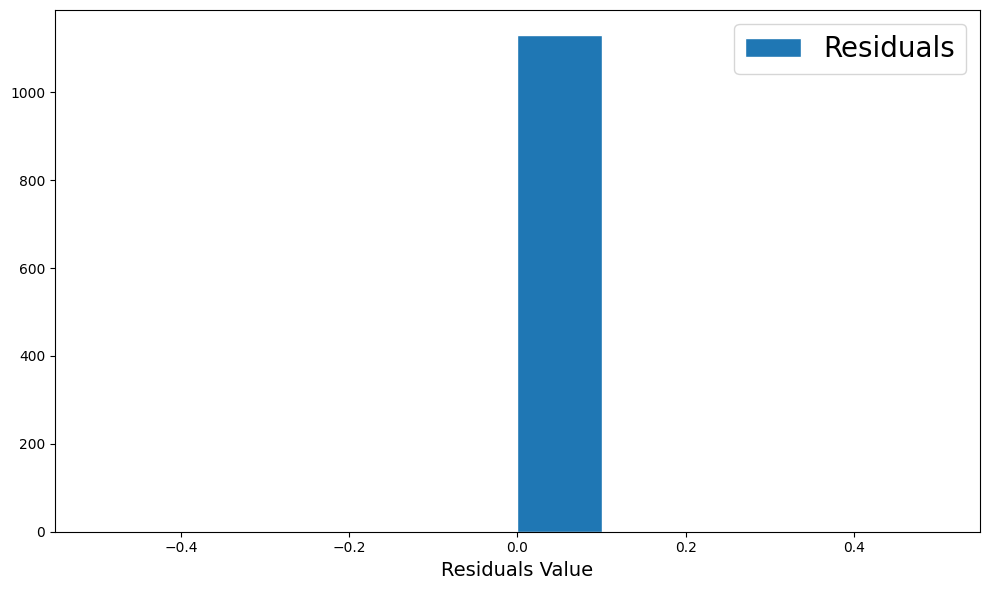

In [91]:
residuals = y_test - predictions_test

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(residuals, edgecolor='white', bins=10, label='Residuals')

ax.set_xlabel('Residuals Value', fontsize=14)
ax.legend(fontsize=20)

plt.tight_layout()
plt.show()

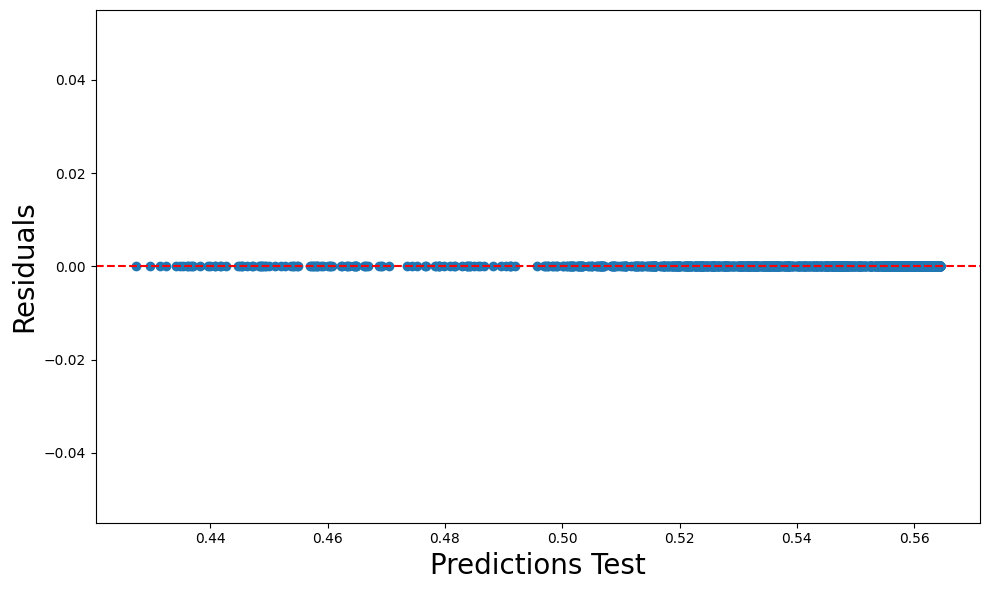

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x=predictions_test, y=residuals)

ax.set_xlabel('Predictions Test', fontsize=20)
ax.set_ylabel('Residuals', fontsize=20)

plt.tight_layout()
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

In [85]:
import numpy as np

In [89]:
def calculate_residuals_statistics(predictions, y_test):
    residuals_v2 = y_test - predictions
    mean_residual = np.mean(residuals_v2)
    std_residual = np.std(residuals_v2)
    
    return mean_residual, std_residual

In [90]:
mean_residual, std_residual = calculate_residuals_statistics(predictions_test, y_test)
print(f"Mean: {mean_residual}\nStandard deviation: {std_residual}")

Mean: 0.0
Standard deviation: 0.0
